In [1]:
import os
import pandas as pd
from datetime import datetime
import seaborn as sns
import math
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import random
from matplotlib import pyplot as plt
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s :%(message)s',level=logging.INFO)


In [2]:
path='./archive/dressipi_recsys2022/'
train_sessions = pd.read_csv(path+"train_sessions.csv")
train_purchase = pd.read_csv(path+"train_purchases.csv")
item_features = pd.read_csv(path+"item_features.csv")
test_leaderboard_sessions = pd.read_csv(path+"test_leaderboard_sessions.csv")
test_final_sessions=pd.read_csv(path+"test_final_sessions.csv")

In [3]:
train_sessions.head()

,session_id,item_id,date
0,3,9655,2020-12-18 21:25:00.373
1,3,9655,2020-12-18 21:19:48.093
2,13,15654,2020-03-13 19:35:27.136
3,18,18316,2020-08-26 19:18:30.833
4,18,2507,2020-08-26 19:16:31.211


In [4]:
train_sessions['date']=pd.to_datetime(train_sessions['date'])
train_purchase['date']=pd.to_datetime(train_purchase['date'])


In [5]:
#ts是时间戳，单个数字变量方便排序
train_sessions['ts']=train_sessions['date'].dt.to_pydatetime()
train_sessions['ts']=train_sessions['ts'].apply(lambda x:x.timestamp())
train_sessions.head()

,session_id,item_id,date,ts
0,3,9655,2020-12-18 21:25:00.373,1.608327e+09
1,3,9655,2020-12-18 21:19:48.093,1.608326e+09
2,13,15654,2020-03-13 19:35:27.136,1.584128e+09
3,18,18316,2020-08-26 19:18:30.833,1.598470e+09
4,18,2507,2020-08-26 19:16:31.211,1.598469e+09


In [6]:
train_sessions=train_sessions.append(train_purchase)
df=train_sessions.sort_values(by=['session_id',"ts"],ascending=True)
df

C:\Users\Smike\AppData\Local\Temp\ipykernel_25472\1676495980.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  train_sessions=train_sessions.append(train_purchase)


,session_id,item_id,date,ts
1,3,9655,2020-12-18 21:19:48.093,1.608326e+09
0,3,9655,2020-12-18 21:25:00.373,1.608327e+09
0,3,15085,2020-12-18 21:26:47.986,NaN
2,13,15654,2020-03-13 19:35:27.136,1.584128e+09
1,13,18626,2020-03-13 19:36:15.507,NaN
...,...,...,...,...
4743804,4440001,19539,2020-10-30 23:37:09.460,1.604101e+09
4743815,4440001,20409,2020-10-30 23:37:20.658,1.604101e+09
4743818,4440001,27852,2020-10-30 23:39:55.186,1.604101e+09
4743806,4440001,20449,2020-10-30 23:40:28.149,1.604101e+09


In [7]:
dic=defaultdict(list)
#创建两个字典，一个是item为key。一个是user为key
for x in tqdm(df[['session_id','item_id']].values):
    dic[f'item_{x[1]}'].append(f'user_{x[0]}')
    dic[f'user_{x[0]}'].append(f'item_{x[1]}')



100%|██████████| 5743820/5743820 [00:20<00:00, 283083.13it/s]


In [8]:
dic_count={}
#一个统计出现次数的字典
#按理来说，分为item和user两种的
for key in dic:
    dic_count[key]=len(dic[key])

In [9]:
item_list=df['item_id'].unique()
user_list=df['session_id'].unique()

#随机游走

In [10]:
#np.where查找一个列表里面指定元素的index
random_user='user_44'
last_item='item_17089'
s=np.where(np.array(dic[random_user])==last_item)
s[0][0]

1

In [11]:
path_length=8
sentences=[]#随机游走之后的结果
num_sentences=1000

max_repeat_times=2*path_length

for _ in tqdm(range(num_sentences)):
    start_item='item_{}'.format(item_list[np.random.randint(0,len(item_list))])
    sentence=[start_item]
    repeat_time=0
    while len(sentence)<path_length:
        last_item=sentence[-1]
        random_user=dic[last_item][np.random.randint(0,dic_count[last_item])]
        next_item_index=np.where(np.array(dic[random_user])==last_item)[0][0]+1

        if next_item_index<=dic_count[random_user]-1:
            next_item=dic[random_user][next_item_index]
            sentence.append(next_item)
        repeat_time+=1
        if repeat_time>max_repeat_times:
            break
    sentences.append(sentence)
        

100%|██████████| 1000/1000 [00:00<00:00, 6132.19it/s]


In [12]:
sentences

[['item_1295',
  'item_26412',
  'item_17402',
  'item_28015',
  'item_13913',
  'item_16542',
  'item_872',
  'item_2845'],
 ['item_11811',
  'item_2250',
  'item_2250',
  'item_2816',
  'item_4575',
  'item_13100',
  'item_2982',
  'item_2982'],
 ['item_25411',
  'item_5767',
  'item_4850',
  'item_14908',
  'item_24166',
  'item_17308',
  'item_25830',
  'item_14811'],
 ['item_10193',
  'item_10036',
  'item_19729',
  'item_9371',
  'item_27404',
  'item_8970',
  'item_19571',
  'item_11707'],
 ['item_27912',
  'item_16004',
  'item_16004',
  'item_21738',
  'item_10514',
  'item_27222',
  'item_28106',
  'item_16314'],
 ['item_5255',
  'item_26691',
  'item_24865',
  'item_21809',
  'item_11618',
  'item_5299',
  'item_5299',
  'item_26908'],
 ['item_21021',
  'item_6038',
  'item_8173',
  'item_15749',
  'item_4718',
  'item_4520',
  'item_24247',
  'item_1639'],
 ['item_7791',
  'item_574',
  'item_14360',
  'item_4125',
  'item_27225',
  'item_20599',
  'item_25273',
  'item_271

4.Word2vec训练

In [13]:
%time 
model=Word2Vec(sentences,vector_size=64)

2025-09-22 16:28:48,644 : INFO :collecting all words and their counts
2025-09-22 16:28:48,645 : INFO :PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-09-22 16:28:48,649 : INFO :collected 5417 word types from a corpus of 7977 raw words and 1000 sentences
2025-09-22 16:28:48,650 : INFO :Creating a fresh vocabulary
2025-09-22 16:28:48,653 : INFO :Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 82 unique words (1.51% of original 5417, drops 5335)', 'datetime': '2025-09-22T16:28:48.653937', 'gensim': '4.3.3', 'python': '3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:08:55) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.19041-SP0', 'event': 'prepare_vocab'}
2025-09-22 16:28:48,654 : INFO :Word2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 511 word corpus (6.41% of original 7977, drops 7466)', 'datetime': '2025-09-22T16:28:48.654934', 'gensim': '4.3.3', 'python': '3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5

CPU times: total: 0 ns
Wall time: 0 ns


In [14]:
model.wv.most_similar('item_8060',topn=10)

[('item_13081', 0.2888331413269043),
 ('item_19912', 0.2779269218444824),
 ('item_25589', 0.2632076144218445),
 ('item_25007', 0.24452534317970276),
 ('item_26853', 0.19933022558689117),
 ('item_5367', 0.18803294003009796),
 ('item_5840', 0.18278378248214722),
 ('item_21890', 0.14744818210601807),
 ('item_1085', 0.14568251371383667),
 ('item_12615', 0.14372698962688446)]

In [15]:
item_map=df['item_id'].value_counts()

In [16]:
item_emb=np.random.rand(len(item_list),64)
item_count=[]
for idx,item in tqdm(enumerate(item_list)):
    item_count.append(item_map[item])
    if f'item_{item}' in model.wv:
        item_emb[idx,:]=model.wv[f'item_{item}']


23618it [00:00, 103344.06it/s]


In [17]:
item_emb

array([[0.80832393, 0.63176129, 0.36522938, ..., 0.65049468, 0.84134828,
        0.61814023],
       [0.90209868, 0.67912058, 0.65531047, ..., 0.20924167, 0.56625883,
        0.23967127],
       [0.66147617, 0.70598824, 0.76755198, ..., 0.98713719, 0.42067736,
        0.59412611],
       ...,
       [0.32314605, 0.04694215, 0.76874044, ..., 0.16933838, 0.71709215,
        0.35686001],
       [0.06799674, 0.02579964, 0.23654703, ..., 0.36744818, 0.65424904,
        0.99726128],
       [0.92396858, 0.32312811, 0.03091147, ..., 0.55826789, 0.73186275,
        0.50931946]])

In [18]:
item_deepwalk_dic=dict(zip(item_list,item_emb))


In [19]:
item_deepwalk_dic[11]

array([0.7615001 , 0.31611119, 0.12689025, 0.80328919, 0.49678931,
       0.22718822, 0.75231773, 0.17066806, 0.03669762, 0.31510215,
       0.52535745, 0.44186427, 0.14990748, 0.03546764, 0.68942038,
       0.23416271, 0.07206967, 0.12223537, 0.42083997, 0.18042894,
       0.84453256, 0.94662014, 0.01892706, 0.39040761, 0.97082568,
       0.55170393, 0.3021104 , 0.78126389, 0.90345315, 0.25746408,
       0.59847593, 0.12968215, 0.59307985, 0.85435222, 0.48141428,
       0.99658975, 0.83101316, 0.45347566, 0.37892292, 0.53283315,
       0.37154144, 0.41066926, 0.3301834 , 0.9338549 , 0.39798494,
       0.4049723 , 0.58907197, 0.15879647, 0.89927454, 0.72294752,
       0.0661193 , 0.02953917, 0.11079719, 0.31592357, 0.88465959,
       0.90225829, 0.72724144, 0.88364009, 0.44828522, 0.01188172,
       0.14672862, 0.82322136, 0.2485693 , 0.39666144])

In [20]:
%time
tsne =TSNE(n_components=2)
tnse_emb =tsne.fit_transform(item_emb)

CPU times: total: 0 ns
Wall time: 0 ns


In [21]:
def plot_embedding(tsne_emb,item_count):
    x_min,x_max=np.min(tsne_emb,0),np.max(tsne_emb,0)
    tsne_emb=(tsne_emb-x_min)/(x_max-x_min)
    plt.figure(dpi=200)
    plt.scatter(tsne_emb[:,0],tsne_emb[:,1],c=item_count)
    plt.colorbar()
    plt.title('TSNE Embedding Plot')
    plt.show()


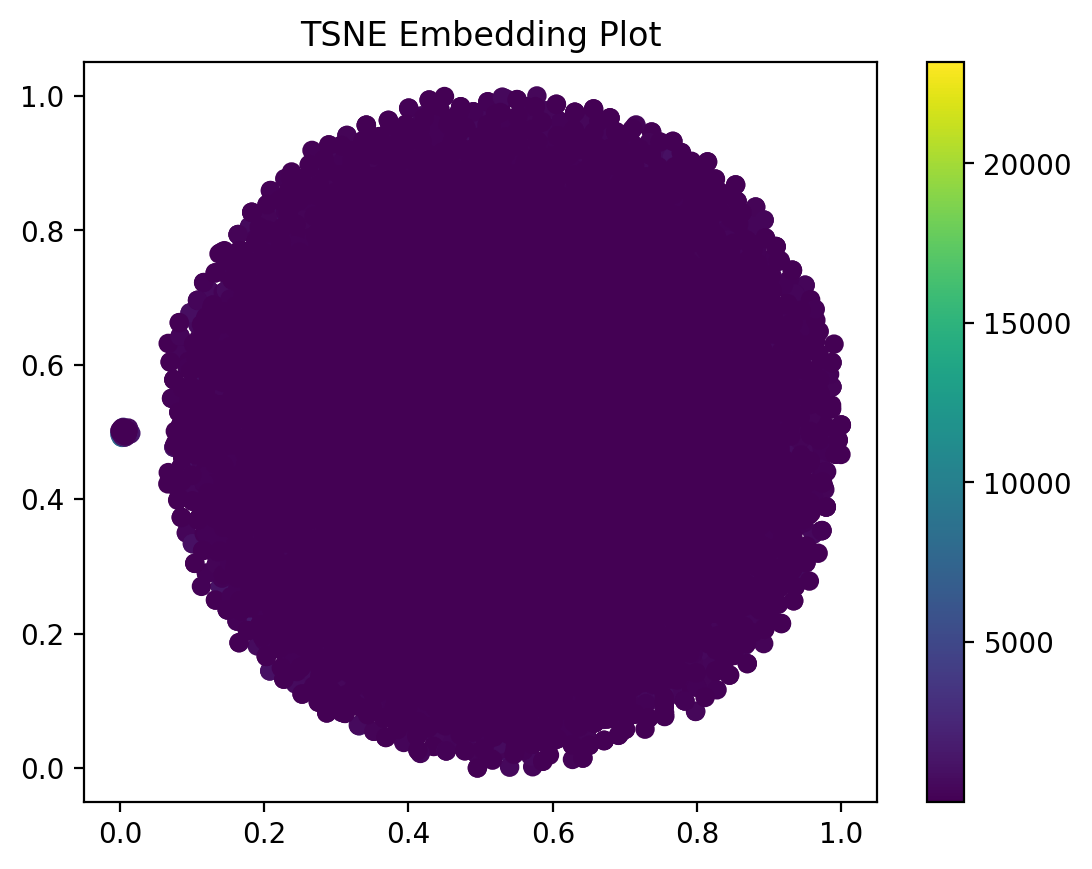

In [22]:
plot_embedding(tnse_emb,item_count)

In [23]:
# ...existing code...

import pickle

# 定义保存文件的路径和名称
output_file_path = './item_deepwalk_embeddings.pkl'

# 将字典保存到文件
with open(output_file_path, 'wb') as f:
    pickle.dump(item_deepwalk_dic, f)

print(f"Item embeddings saved to {output_file_path}")

Item embeddings saved to ./item_deepwalk_embeddings.pkl
